# Proyek Capstone: [Prediksi Konsumsi Energi Listrik Rumah Tangga Bulanan]
- **Tema Capstone:**  Sustainable Living & Responsible Consumption
- **ID Tim:**  CC26-PRU468
- **Anggota**:
  - Muhammad Fawaz Hadimatulloh [CACC253D6Y0950]
  - Mochamad Nurdin Al Ghifary Kurniawan [CFCC557D6Y1705]
  - Audrey Mediliani [CACC237D6X1169]
  - Devin Rayhan Putra Aswin [CDCC284D6Y2389]
  - Dafa Ashari Siregar [ CFCC946D6Y1294]

### **Menentukan Pertanyaan Bisnis**

Apakah rata-rata konsumsi listrik (Global Active Power) pada hari akhir pekan (Sabtu & Minggu) lebih tinggi minimal 10% dibandingkan hari kerja (Senin-Jumat) pada rumah tangga tersebut selama periode 2007–2009?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
# 1. Baca data tanpa parse_dates di awal untuk menghindari warning nested sequence
df = pd.read_csv(
    'household_power_consumption.txt',
    sep=';',
    low_memory=False,
    na_values=['?']
)

# 2. Gabungkan kolom Date dan Time, lalu ubah ke datetime dengan format yang benar
# Dataset ini formatnya Day/Month/Year (misal: 16/12/2006)
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

# 3. Jadikan datetime sebagai index dan hapus kolom aslinya
df.set_index('datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Intip hasilnya
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


### Assessing Data

In [ ]:
# Cek informasi umum (tipe data dan jumlah baris)
print("--- Info Dataset ---")
df.info()

# Cek jumlah data yang kosong (NaN)
print("\n--- Jumlah Data Kosong ---")
print(df.isna().sum())

# Cek apakah ada baris duplikat
print(f"\nJumlah Duplikat: {df.duplicated().sum()}")

# Cek statistik deskriptif untuk melihat kejanggalan angka (outlier)
df.describe()

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB

--- Jumlah Data Kosong ---
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Jumlah Duplikat: 168560


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


### Cleaning Data

In [ ]:
# 1. Resampling ke Harian (D = Daily)
# Mengambil rata-rata konsumsi per hari
df_daily = df.resample('D').mean()

# 2. Verifikasi Data Harian
print(f"Jumlah baris data harian: {len(df_daily)}")
print("Check missing values di df_daily:")
print(df_daily.isna().sum())

# 3. Simpan ke Lokal (CSV & TXT)
df_daily.to_csv('household_daily_clean.csv', index=True)
df_daily.to_csv('household_daily_clean.txt', sep='\t', index=True)

print("\nData harian berhasil disimpan!")
df_daily.head()

Jumlah baris data harian: 1442
Check missing values di df_daily:
Global_active_power      9
Global_reactive_power    9
Voltage                  9
Global_intensity         9
Sub_metering_1           9
Sub_metering_2           9
Sub_metering_3           9
dtype: int64

Data harian berhasil disimpan!


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972


In [ ]:
# 1. Cek rentang waktu harian (apakah dari 2006 sampai 2010 sudah masuk semua?)
print(f"Data harian dimulai dari: {df_daily.index.min()}")
print(f"Data harian berakhir di: {df_daily.index.max()}")

# 2. Cek apakah ada angka negatif di data harian
print(f"\nApakah ada data harian yang negatif? {(df_daily < 0).any().any()}")

# 3. Intip statistik singkat data harian
df_daily.describe()

Data harian dimulai dari: 2006-12-16 00:00:00
Data harian berakhir di: 2010-11-26 00:00:00

Apakah ada data harian yang negatif? False


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000
mean,1.092048,0.123816,240.836421,4.629728,1.123143,1.298620,6.444100
std,0.420415,0.034131,2.045493,1.741352,1.113913,1.461039,2.568978
min,0.173818,0.057811,231.088229,0.808333,0.000000,0.000000,0.000000
25%,0.816776,0.099188,240.094778,3.503333,0.440972,0.299306,4.638889
50%,1.080732,0.119092,240.965688,4.556111,0.775694,0.479167,6.447222
75%,1.323926,0.141454,241.878583,5.540556,1.545139,1.897222,8.155556
max,3.314851,0.290162,247.435007,14.028056,7.767894,8.409028,16.488194


In [ ]:
# 1. Simpan ke CSV (Pemisah Koma)
df_monthly.to_csv('household_monthly_clean.csv', index=True)

# 2. Simpan ke TXT (Pemisah Tab agar rapi saat dibuka di Notepad)
df_monthly.to_csv('household_monthly_clean.txt', sep='\t', index=True)

print("Berhasil menyimpan data ke format .csv dan .txt!")

## Exploratory Data Analysis (EDA)

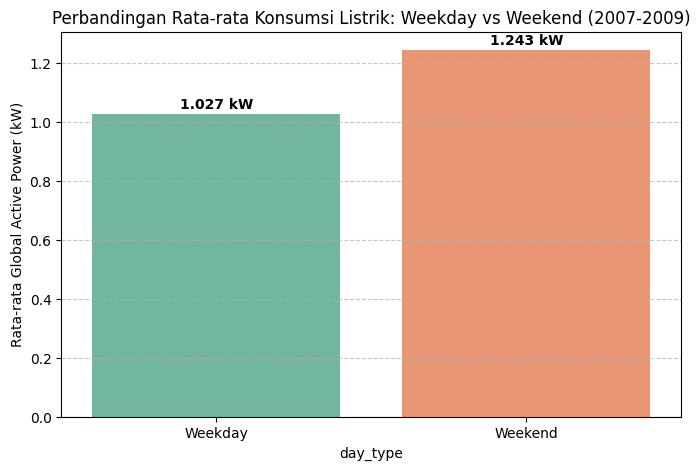

In [ ]:
# 1. Filter data untuk periode 2007 - 2009
df_filtered = df_daily.loc['2007':'2009'].copy()

# 2. Hitung rata-rata konsumsi listrik untuk Weekday vs Weekend
avg_consumption = df_filtered.groupby('day_type')['Global_active_power'].mean()

# 3. Visualisasi Bar Plot (Sudah diperbaiki dari Future Warning)
plt.figure(figsize=(8, 5))
sns.barplot(
    x=avg_consumption.index,
    y=avg_consumption.values,
    hue=avg_consumption.index,  # Menghilangkan warning
    palette='Set2',
    legend=False
)

plt.title('Perbandingan Rata-rata Konsumsi Listrik: Weekday vs Weekend (2007-2009)', fontsize=12)
plt.ylabel('Rata-rata Global Active Power (kW)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label angka di atas bar
for i, val in enumerate(avg_consumption.values):
    plt.text(i, val + 0.02, f"{val:.3f} kW", ha='center', fontweight='bold')

plt.show()

**Hasil:** Rata-rata konsumsi listrik harian pada hari kerja (Weekday) adalah 1.027 kW, sedangkan pada akhir pekan (Weekend) melonjak menjadi 1.243 kW.

**Insight:** Terjadi kenaikan konsumsi sebesar 21.08% di akhir pekan. Angka ini secara objektif membuktikan bahwa hipotesis bisnismu Benar/Terbukti

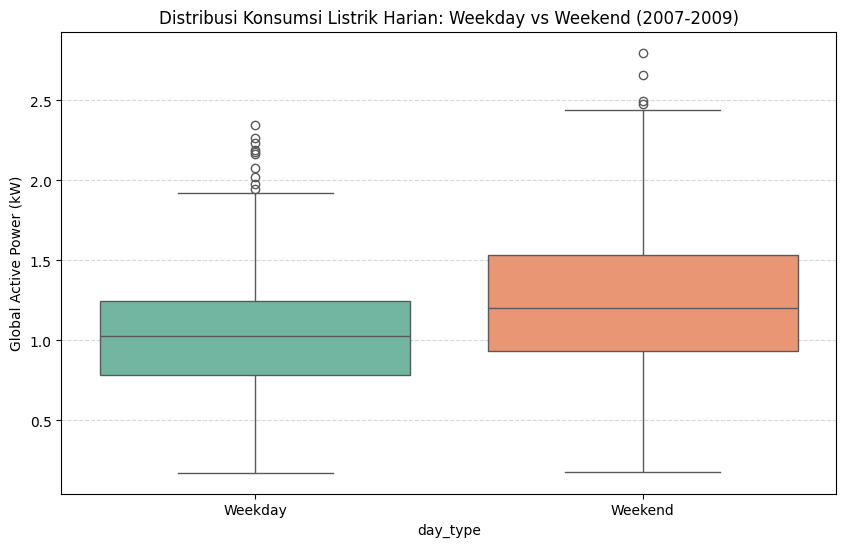

In [ ]:
# Visualisasi Box Plot (Sudah diperbaiki dari Future Warning)
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_filtered,
    x='day_type',
    y='Global_active_power',
    hue='day_type',  # Menghilangkan warning
    palette='Set2',
    legend=False
)

plt.title('Distribusi Konsumsi Listrik Harian: Weekday vs Weekend (2007-2009)', fontsize=12)
plt.ylabel('Global Active Power (kW)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Hasil**: Kotak distribusi (interquartile range) pada kategori Weekend bergeser lebih tinggi ke atas dibandingkan Weekday. Selain itu, garis batas atas (whiskers) dan sebaran titik pencilan (outliers) harian jauh lebih banyak menumpuk di area Weekend.

**Insight**: Ini menunjukkan bahwa di akhir pekan, penggunaan listrik tidak hanya naik secara rata-rata, tetapi juga sering mengalami lonjakan beban puncak yang ekstrem pada hari-hari tertentu. Aktivitas di akhir pekan jauh lebih tidak stabil dan rawan memicu pembengkakan biaya akibat penggunaan alat berat secara simultan.

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:975: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


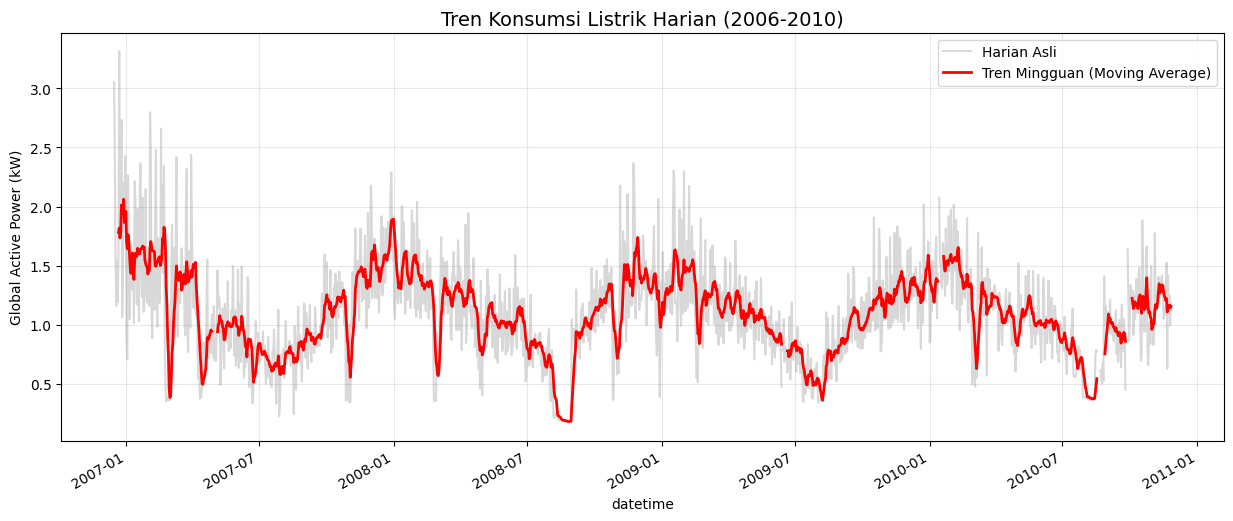

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Plot data asli (tipis)
plt.plot(df_daily.index, df_daily['Global_active_power'], alpha=0.3, label='Harian Asli', color='gray')

# Plot rata-rata bergerak 7 hari (tebal) agar tren lebih jelas
df_daily['Global_active_power'].rolling(window=7).mean().plot(color='red', linewidth=2, label='Tren Mingguan (Moving Average)')

plt.title('Tren Konsumsi Listrik Harian (2006-2010)', fontsize=14)
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Hasil**: Grafik menunjukkan pola naik-turun berbentuk gelombang yang sangat konsisten setiap tahunnya. Konsumsi listrik selalu mencapai puncak tertinggi (peak) di sekitar awal tahun (Desember - Januari) dan mencapai titik terendah (trough) di pertengahan tahun (sekitar bulan Juli - Agustus).

**Insight**: Rumah tangga ini memiliki ketergantungan yang sangat tinggi pada musim. Lonjakan di musim dingin/awal tahun kemungkinan besar dipicu oleh penggunaan alat pemanas (heater) atau sistem penghangat air yang bekerja ekstra keras, sedangkan di pertengahan tahun konsumsi listrik jauh lebih hemat.

In [ ]:
# ekstrak fitur waktu menjadi kolom numerik untuk Model ML
df_daily['year'] = df_daily.index.year
df_daily['month'] = df_daily.index.month
df_daily['day'] = df_daily.index.day
df_daily['day_of_week'] = df_daily.index.dayofweek  # 0=Senin, 6=Minggu
df_daily['is_weekend'] = (df_daily['day_of_week'] >= 5).astype(int)  # 1=Weekend, 0=Weekday

# cek struktur akhir data yang sudah matang
print("Struktur Data Siap Model:")
print(df_daily[['Global_active_power', 'year', 'month', 'day', 'day_of_week', 'is_weekend']].head())